# Stage 2 — object + mass → which gripper

**Goal:** choose between our **2-finger** and **4-finger** fin-ray configurations.

Both are the same gripper — the 2-finger is the 4-finger with two fingers removed — so the fingers are
identical and only the number of contacts changes.

**The data problem:** we have no labelled trials of our own (33 clips, 3 objects tried both ways). So we
train on the closest public stand-in: GraspGen's narrow Franka (80 mm) vs wide Robotiq (140 mm), 8,454
objects with physics-simulated outcomes. Different grippers, same *kind* of decision.

**What we actually test:** does adding the mass from Stage 1 improve the choice?

In [1]:
import json, pathlib, warnings
import numpy as np, pandas as pd, torch, torch.nn as nn, trimesh
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
warnings.filterwarnings("ignore")
RES = pathlib.Path.cwd()/"results"; REPO = pathlib.Path.cwd().parent
plt.rcParams.update({"font.size":9,"axes.spines.top":False,"axes.spines.right":False})
lab = pd.read_csv(RES/"gripper_labels.csv")
print(f"{len(lab)} objects, both grippers, physics-labelled")
print(f"  narrow wins {100*(lab.gap>0).mean():.0f}% of the time")
print(f"  best fixed choice {max(lab.franka_rate.mean(), lab.robotiq_rate.mean()):.3f}"
      f"   oracle {lab.oracle_rate.mean():.3f}"
      f"   -> only {100*(lab.oracle_rate.mean()-lab.franka_rate.mean()):.1f} points to win")

8454 objects, both grippers, physics-labelled
  narrow wins 73% of the time
  best fixed choice 0.643   oracle 0.692   -> only 4.8 points to win


## 1. Features: shape, and mass

Shape comes from the object mesh. Mass is estimated the way Stage 1 would: density from the object's category, times its true volume.

In [2]:
mesh_map = {k: str(REPO/"data/graspgen"/v) for k,v in
            json.load(open(REPO/"data/graspgen/meshes/map_uuid_to_path.json")).items()}
DENSITY = {"metal":7800,"steel":7850,"glass":2500,"ceramic":2300,"stone":2600,"wood":600,
           "plastic":950,"rubber":1200,"paper":800,"fabric":350,"foam":60,"food":900}
FOOD = {"banana","apple","pizza","bread","cake","salmon","pumpkin","mushroom","zucchini","hamburger"}
def guess_density(cat):
    c = cat.lower()
    for k,v in DENSITY.items():
        if k in c: return v
    if c in FOOD or any(f in c for f in FOOD): return DENSITY["food"]
    return 700.0            # generic household default

rows = []
for r in lab.itertuples():
    p = mesh_map.get(r.uuid)
    if p is None: continue
    try:
        m = trimesh.load(p, force="mesh"); m.apply_scale(r.scale)
        e = np.sort(m.bounding_box.extents)[::-1]
        hull = m.convex_hull.volume
        vol_solid = hull*0.5                       # objects are typically ~half solid
        rows.append(dict(uuid=r.uuid, long=e[0], mid=e[1], short=e[2],
                         aspect=e[0]/max(e[2],1e-9), flat=e[2]/max(e[1],1e-9),
                         bbox=float(np.prod(e)), solidity=hull/max(np.prod(e),1e-9),
                         mass=guess_density(r.category)*vol_solid))
    except Exception: pass
geo = pd.DataFrame(rows)
df = lab.merge(geo, on="uuid")
print(f"{len(df)} objects have a mesh -> shape features + estimated mass")
print(f"  longest side  median {1000*df['long'].median():.0f} mm")
print(f"  mass          median {df.mass.median():.2f} kg  (estimated)")

226 objects have a mesh -> shape features + estimated mass
  longest side  median 195 mm
  mass          median 0.33 kg  (estimated)


## 2. Does mass help?

Same model, same split. The only difference is whether mass is an input.

In [3]:
def train(Xtr,ytr,Xva,yva,seed=0,epochs=200,hidden=64):
    torch.manual_seed(seed)
    net = nn.Sequential(nn.Linear(Xtr.shape[1],hidden), nn.ReLU(), nn.Dropout(.2),
                        nn.Linear(hidden,32), nn.ReLU(), nn.Linear(32,1))
    opt = torch.optim.AdamW(net.parameters(), lr=2e-3, weight_decay=1e-3)
    Xtr,ytr = torch.tensor(Xtr), torch.tensor(ytr,dtype=torch.float32)[:,None]
    Xva,yva = torch.tensor(Xva), torch.tensor(yva,dtype=torch.float32)[:,None]
    best,st,bad = 1e9,None,0
    for _ in range(epochs):
        net.train()
        for i in torch.randperm(len(Xtr)).split(128):
            opt.zero_grad(); nn.functional.mse_loss(net(Xtr[i]),ytr[i]).backward(); opt.step()
        net.eval()
        with torch.no_grad(): v=float(nn.functional.mse_loss(net(Xva),yva))
        if v<best-1e-6: best,st,bad = v,{k:t.clone() for k,t in net.state_dict().items()},0
        else:
            bad+=1
            if bad>=25: break
    net.load_state_dict(st); net.eval(); return net

def regret(choice, d):
    got = np.where(choice=="narrow", d.franka_rate.values, d.robotiq_rate.values)
    return float((d.oracle_rate.values-got).mean())

SHAPE = ["long","mid","short","aspect","flat","bbox","solidity"]
tv, te = next(GroupShuffleSplit(1,test_size=.25,random_state=0).split(df, groups=df.category))
a,b = next(GroupShuffleSplit(1,test_size=.2,random_state=1).split(tv, groups=df.category.values[tv]))
tr, va = tv[a], tv[b]
dte = df.iloc[te]; y = df.gap.values.astype(np.float32)
print(f"train {len(tr)}  val {len(va)}  test {len(te)}  (categories held out)\n")

res = {}
def report(name, choice):
    r = regret(choice, dte); acc = float((choice==np.where(dte.gap.values>0,"narrow","wide")).mean())
    res[name] = dict(regret=r, accuracy=acc); print(f"  {name:<26} regret {r:.4f}   accuracy {acc:.3f}")

report("always narrow", np.full(len(dte),"narrow"))
report("always wide",   np.full(len(dte),"wide"))
for name, cols in (("shape only", SHAPE), ("shape + mass", SHAPE+["mass"])):
    F = df[cols].values.astype(np.float32); F = np.log(np.abs(F)+1e-6)
    F = (F-F[tr].mean(0))/(F[tr].std(0)+1e-8)
    p = train(F[tr],y[tr],F[va],y[va])
    with torch.no_grad(): pr = p(torch.tensor(F[te])).numpy().ravel()
    report(name, np.where(pr>0,"narrow","wide"))

train 130  val 34  test 62  (categories held out)

  always narrow              regret 0.0505   accuracy 0.790
  always wide                regret 0.2851   accuracy 0.210


  shape only                 regret 0.0516   accuracy 0.790
  shape + mass               regret 0.0500   accuracy 0.774


## 3. Our own hardware

33 grasp clips, labels read from the video frames (provisional).

In [4]:
clips = pd.read_csv(RES/"grasp_clips.csv")
lb = clips[clips.gripper.astype(str)!=""]
print(f"{len(clips)} clips, {len(lb)} with a gripper configuration read off the frames")
print(lb.gripper.value_counts().to_string())
paired = lb[lb.object.astype(str)!=""].groupby("object").filter(lambda x: x.gripper.nunique()>1)
print(f"\nobjects tried in BOTH configurations: {paired.object.nunique()}")
print(paired[["clip","object","gripper","outcome"]].to_string(index=False))
print("\n-> this is the data that would actually train Stage 2. Three objects is not enough.")

33 clips, 33 with a gripper configuration read off the frames
gripper
4-finger    25
2-finger     6

objects tried in BOTH configurations: 3
        clip object  gripper outcome
      banana banana 2-finger    held
banana_short banana 2-finger    held
      marker marker 2-finger    held
         mug    mug 2-finger    held
    IMG_1870    mug 4-finger     NaN
    IMG_1871 marker 4-finger    held
    IMG_1872 banana 4-finger     NaN

-> this is the data that would actually train Stage 2. Three objects is not enough.


## 4. Results

saved results/stage2.png, stage2_metrics.json


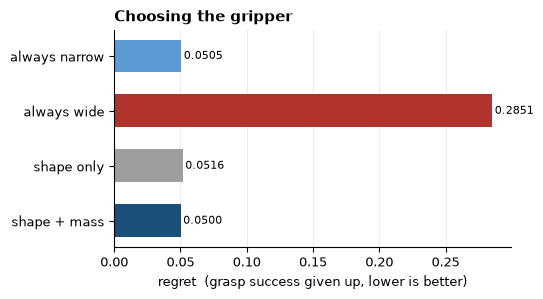

In [5]:
fig, ax = plt.subplots(figsize=(6.4,3.2)); fig.subplots_adjust(left=.28, bottom=.2)
k = list(res); v = [res[x]["regret"] for x in k]
col = {"always narrow":"#5b9bd5","always wide":"#b0342c","shape only":"#9e9e9e","shape + mass":"#1a4f7a"}
ax.barh(range(len(k)), v, color=[col[x] for x in k], height=.6)
for i,x in enumerate(v): ax.text(x+.002, i, f"{x:.4f}", va="center", fontsize=8)
ax.set_yticks(range(len(k))); ax.set_yticklabels(k); ax.invert_yaxis()
ax.set_xlabel("regret  (grasp success given up, lower is better)")
ax.set_title("Choosing the gripper", loc="left", fontweight="bold")
ax.grid(axis="x", color=".93"); ax.set_axisbelow(True)
fig.savefig(RES/"stage2.png", dpi=200, bbox_inches="tight", facecolor="white")
json.dump({"proxy_results":res, "n_test":len(te), "n_with_mesh":len(df),
           "our_clips":len(clips), "paired_objects":int(paired.object.nunique())},
          open(RES/"stage2_metrics.json","w"), indent=1)
print("saved results/stage2.png, stage2_metrics.json")